In [5]:
import matplotlib.pyplot as plt
import numpy as np
from featuregraph import get_block_coordinates, get_valid_transformations, get_candidate_transformations, plot_arc_agi

In [6]:
test_grid = np.array([
    [8, 3],
    [0, 5],
])

numeric_instruction_layout = np.array([[0, 3],
       [4, 5]])

valid_transformations = get_valid_transformations(test_grid)
instruction_layout = np.array([[valid_transformations[i]['name'] for i in instruction] for instruction in numeric_instruction_layout])

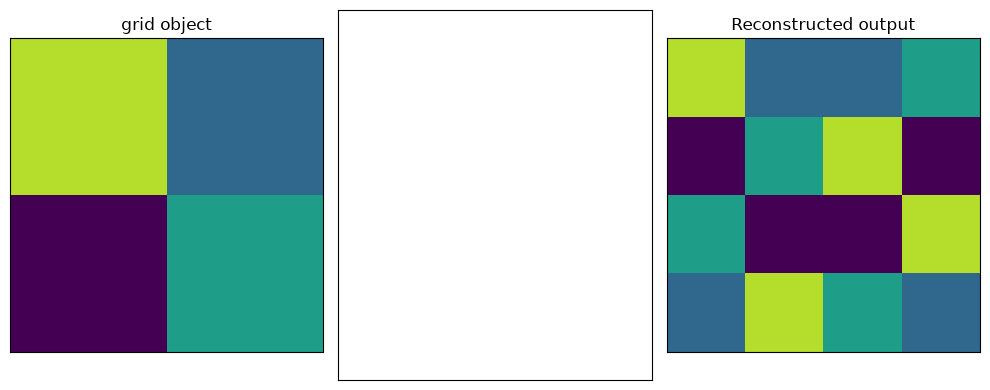

In [7]:
predictions = []

for grid in [test_grid]:

    grid_height, grid_width = grid.shape
    predicted_height = instruction_layout.shape[0] * grid_height
    predicted_width = instruction_layout.shape[1] * grid_width
    predicted_shape = (predicted_height, predicted_width)

    number_of_block_rows = predicted_height // grid_height
    number_of_block_columns = predicted_width // grid_width

    block_coordinates = get_block_coordinates(grid.shape, predicted_shape)
    candidate_transformations = np.array([get_candidate_transformations(v['value'], block_coordinates) for v in valid_transformations]).T

    cell_indices = np.arange(candidate_transformations.shape[0])
    cell_instructions = numeric_instruction_layout[block_coordinates[:,0], block_coordinates[:,1]]
    manual_output = candidate_transformations[cell_indices, cell_instructions].reshape(predicted_shape)

    plot_arc_agi(grid, output=None, manual_output=manual_output)
    predictions.append(manual_output.copy())

In [8]:
instruction_layout

array([['copy', 'rotate_90'],
       ['rotate_180', 'rotate_270']], dtype='<U10')